# **함수의 미분**

f(x)   = x**3 - 3*x**2 + 2
f'(x)  = 3*x*(x - 2)
f''(x) = 6*x - 6

f''(x) = 0  ->  x = [1]
  at x = 1: f(x) = 0


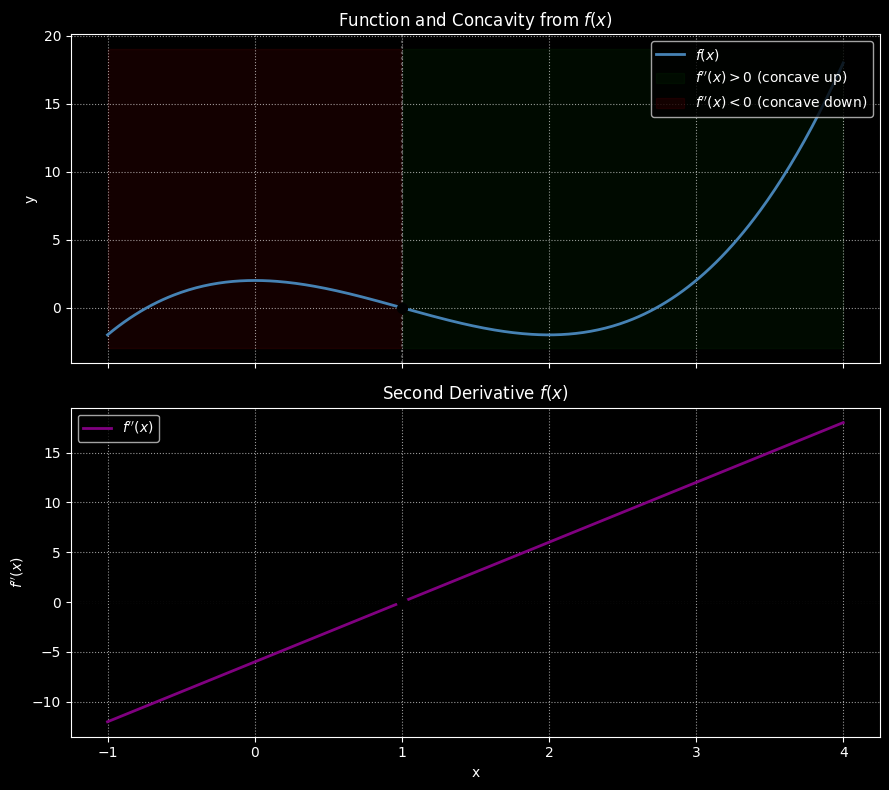

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.Symbol('x')

f = x**3 - 3 * x**2 + 2
f1 = sp.diff(f, x)
f2 = sp.diff(f, x, 2)   

print(f'f(x)   = {f}')
print(f"f'(x)  = {sp.simplify(f1)}")
print(f"f''(x) = {sp.simplify(f2)}")

inflection_x = sp.solve(f2, x)
print(f"\nf''(x) = 0  ->  x = {inflection_x}")

for xi in inflection_x:
    print(f"  at x = {xi}: f(x) = {f.subs(x, xi)}")

f_num = sp.lambdify(x, f, 'numpy')
f1_num = sp.lambdify(x, f1, 'numpy')
f2_num = sp.lambdify(x, f2, 'numpy')

x_domain = np.linspace(-1, 4, 400)
y = f_num(x_domain)
y1 = f1_num(x_domain)
y2 = f2_num(x_domain)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax0 = axes[0]
ax0.plot(x_domain, y, color='steelblue', linewidth=2, label=r'$f(x)$')

concave_up = y2 > 0
concave_down = y2 < 0
ax0.fill_between(x_domain, y.min() - 1, y.max() + 1, where=concave_up,
                 color='green', alpha=0.08, label=r"$f''(x) > 0$ (concave up)")
ax0.fill_between(x_domain, y.min() - 1, y.max() + 1, where=concave_down,
                 color='red', alpha=0.08, label=r"$f''(x) < 0$ (concave down)")

for xi in inflection_x:
    yi = float(f.subs(x, xi))
    ax0.scatter([float(xi)], [yi], color='black', s=50, zorder=5)
    ax0.axvline(float(xi), color='gray', linestyle=':', alpha=0.7)

ax0.set_ylabel('y')
ax0.set_title(r'Function and Concavity from $f''(x)$')
ax0.legend(loc='upper right')
ax0.grid(True, linestyle=':', alpha=0.6)

ax1 = axes[1]
ax1.plot(x_domain, y2, color='purple', linewidth=2, label=r"$f''(x)$")
ax1.axhline(0, color='black', linewidth=0.8)
for xi in inflection_x:
    ax1.scatter([float(xi)], [0], color='black', s=50, zorder=5)

ax1.set_xlabel('x')
ax1.set_ylabel(r"$f''(x)$")
ax1.set_title(r'Second Derivative $f''(x)$')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# **합성함수 미분법**


In [3]:
# y = f(g(x))  ->  dy/dx = f'(g(x)) * g'(x)

x, u = sp.symbols('x u')

g = 2 * x + 1          # inner function
f_u = u**3             # outer function f(u)

y = f_u.subs(u, g)     # y = (2x + 1)^3

g_prime = sp.diff(g, x)
f_prime_u = sp.diff(f_u, u)

print(f'g(x)     = {g}')
print(f'f(u)     = {f_u}')
print(f'y = f(g) = {sp.expand(y)}')
print(f"\ng'(x)    = {g_prime}")
print(f"f'(u)    = {f_prime_u}")

# chain rule
chain_rule = f_prime_u.subs(u, g) * g_prime
direct = sp.diff(y, x)

print(f"\n[f'(g(x))] * g'(x) = {sp.simplify(chain_rule)}")
print(f"direct diff(y, x)  = {sp.simplify(direct)}")

if sp.simplify(chain_rule - direct) == 0:
    print('\nchain rule: f\'(g(x)) * g\'(x) = dy/dx  (verified)')

# numeric check at x = 1
x_val = 1
print(f"\ncheck at x = {x_val}:")
print(f"  chain rule = {float(chain_rule.subs(x, x_val))}")
print(f"  direct     = {float(direct.subs(x, x_val))}")


g(x)     = 2*x + 1
f(u)     = u**3
y = f(g) = 8*x**3 + 12*x**2 + 6*x + 1

g'(x)    = 2
f'(u)    = 3*u**2

[f'(g(x))] * g'(x) = 6*(2*x + 1)**2
direct diff(y, x)  = 6*(2*x + 1)**2

chain rule: f'(g(x)) * g'(x) = dy/dx  (verified)

check at x = 1:
  chain rule = 54.0
  direct     = 54.0


# **몫의 미분법**


In [ ]:
# y = f(x) / g(x)  ->  y' = (f'g - fg') / g^2

x = sp.Symbol('x')

f = x**2 + 2
g = x + 1
y = f / g

f_prime = sp.diff(f, x)
g_prime = sp.diff(g, x)

print(f'f(x) = {f}')
print(f'g(x) = {g}')
print(f'y    = f/g = {sp.simplify(y)}')
print(f"\nf'(x) = {f_prime}")
print(f"g'(x) = {g_prime}")

# quotient rule
quotient_rule = (f_prime * g - f * g_prime) / g**2
direct = sp.diff(y, x)

print(f"\n(f'g - fg') / g^2 = {sp.simplify(quotient_rule)}")
print(f"direct diff(y, x)  = {sp.simplify(direct)}")

if sp.simplify(quotient_rule - direct) == 0:
    print("\nquotient rule: (f'g - fg') / g^2 = dy/dx  (verified)")

x_val = 2
print(f"\ncheck at x = {x_val}:")
print(f"  quotient rule = {float(quotient_rule.subs(x, x_val))}")
print(f"  direct        = {float(direct.subs(x, x_val))}")


f(x) = x**2 + 2
g(x) = x + 1
y    = f/g = (x**2 + 2)/(x + 1)

f'(x) = 2*x
g'(x) = 1

(f'g - fg') / g^2 = (-x**2 + 2*x*(x + 1) - 2)/(x + 1)**2
direct diff(y, x)  = (-x**2 + 2*x*(x + 1) - 2)/(x + 1)**2

quotient rule: (f'g - fg') / g^2 = dy/dx  (verified)

check at x = 2:
  quotient rule = 0.6666666666666666
  direct        = 0.6666666666666666


# **음함수 미분법**


In [8]:
# F(x, y) = 0  ->  differentiate both sides w.r.t. x  ->  dy/dx = -F_x / F_y

x, y = sp.symbols('x y', real=True)

eq = x**2 + y**2 - 1   # x^2 + y^2 = 1

print(f'equation: {eq} = 0')

# method 1: implicit diff (SymPy idiff)
dy_dx_idiff = sp.idiff(eq, y, x)
print(f"\nidiff result: dy/dx = {dy_dx_idiff}")

# method 2: differentiate both sides manually
y_func = sp.Function('y')(x)
eq_sub = eq.subs(y, y_func)
lhs_diff = sp.diff(eq_sub, x)
dy_dx_manual = sp.solve(lhs_diff, sp.diff(y_func, x))[0]
print(f"manual result: dy/dx = {dy_dx_manual}")

if sp.simplify(dy_dx_manual - dy_dx_idiff.subs(y, y_func)) == 0:
    print('\nimplicit diff: idiff and manual match  (verified)')

# compare with explicit form y = sqrt(1 - x^2)
y_explicit = sp.sqrt(1 - x**2)
direct = sp.diff(y_explicit, x)
print(f"\nexplicit y = sqrt(1-x^2):")
print(f"  dy/dx = {sp.simplify(direct)}")

x_val = sp.Rational(3, 5)
y_val = y_explicit.subs(x, x_val)
print(f"\ncheck at x = {x_val} (y = {sp.simplify(y_val)}):")
print(f"  implicit  = {float(dy_dx_idiff.subs({x: x_val, y: y_val}))}")
print(f"  explicit  = {float(direct.subs(x, x_val))}")


equation: x**2 + y**2 - 1 = 0

idiff result: dy/dx = -x/y
manual result: dy/dx = -x/y(x)

implicit diff: idiff and manual match  (verified)

explicit y = sqrt(1-x^2):
  dy/dx = -x/sqrt(1 - x**2)

check at x = 3/5 (y = 4/5):
  implicit  = -0.75
  explicit  = -0.75


# **역함수 미분법**


In [7]:
# if g = f^(-1), then g'(y) = 1 / f'(g(y))

x, y = sp.symbols('x y', real=True)

f = x**3
f_prime = sp.diff(f, x)

g = y**sp.Rational(1, 3)   # g(y) = cube root of y  (inverse of f)
g_prime = sp.diff(g, y)

print(f'f(x)     = {f}')
print(f"f'(x)    = {f_prime}")
print(f'g(y)     = f^(-1)(y) = {g}')
print(f"g'(y)    = {sp.simplify(g_prime)}")

# inverse function rule: g'(y) = 1 / f'(g(y))
inverse_rule = 1 / f_prime.subs(x, g)

print(f"\n1 / f'(g(y)) = {sp.simplify(inverse_rule)}")

if sp.simplify(inverse_rule - g_prime) == 0:
    print("\ninverse rule: g'(y) = 1 / f'(g(y))  (verified)")

# numeric check at y = 8  ->  g(8) = 2,  f'(2) = 12
y_val = 8
x_val = g.subs(y, y_val)
print(f"\ncheck at y = {y_val} (x = g(y) = {x_val}):")
print(f"  g'(y)         = {float(g_prime.subs(y, y_val))}")
print(f"  1 / f'(g(y))  = {float(inverse_rule.subs(y, y_val))}")
print(f"  1 / f'({x_val})       = {float(1 / f_prime.subs(x, x_val))}")


f(x)     = x**3
f'(x)    = 3*x**2
g(y)     = f^(-1)(y) = y**(1/3)
g'(y)    = 1/(3*y**(2/3))

1 / f'(g(y)) = 1/(3*y**(2/3))

inverse rule: g'(y) = 1 / f'(g(y))  (verified)

check at y = 8 (x = g(y) = 2):
  g'(y)         = 0.08333333333333333
  1 / f'(g(y))  = 0.08333333333333333
  1 / f'(2)       = 0.08333333333333333


# **매개변수로 나타낸 함수의 미분법**


In [6]:
# x = f(t), y = g(t)  ->  dy/dx = (dy/dt) / (dx/dt)

t = sp.Symbol('t', real=True)

x_param = sp.cos(t)
y_param = sp.sin(t)

dx_dt = sp.diff(x_param, t)
dy_dt = sp.diff(y_param, t)
dy_dx_param = dy_dt / dx_dt

print(f'x(t) = {x_param}')
print(f'y(t) = {y_param}')
print(f"\ndx/dt = {dx_dt}")
print(f"dy/dt = {dy_dt}")
print(f"\ndy/dx = (dy/dt)/(dx/dt) = {sp.simplify(dy_dx_param)}")

# same curve satisfies x^2 + y^2 = 1, so dy/dx = -x/y
dy_dx_from_xy = -x_param / y_param
print(f"from x^2+y^2=1: dy/dx = -x/y = {sp.simplify(dy_dx_from_xy)}")

if sp.simplify(dy_dx_param - dy_dx_from_xy) == 0:
    print('\nparametric rule: (dy/dt)/(dx/dt) = dy/dx  (verified)')

# numeric check at t = pi/4
t_val = sp.pi / 4
x_val = x_param.subs(t, t_val)
y_val = y_param.subs(t, t_val)
print(f"\ncheck at t = pi/4  (x = {sp.simplify(x_val)}, y = {sp.simplify(y_val)}):")
print(f"  parametric  = {float(dy_dx_param.subs(t, t_val))}")
print(f"  -x/y        = {float(dy_dx_from_xy.subs(t, t_val))}")


x(t) = cos(t)
y(t) = sin(t)

dx/dt = -sin(t)
dy/dt = cos(t)

dy/dx = (dy/dt)/(dx/dt) = -1/tan(t)
from x^2+y^2=1: dy/dx = -x/y = -1/tan(t)

parametric rule: (dy/dt)/(dx/dt) = dy/dx  (verified)

check at t = pi/4  (x = sqrt(2)/2, y = sqrt(2)/2):
  parametric  = -1.0
  -x/y        = -1.0
